## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [183]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [184]:
import warnings
warnings.filterwarnings('ignore')

In [185]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_EL = 'κεντρικης μακεδονιας'

In [186]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [187]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)
#wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Timeline_2022.csv', encoding=enc)

In [188]:
timeline_file.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_lat,lst_lon,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.35117,40.59303,2023-08-01,2023,8,2023-08-01,40.592622,22.352330,0.693092,0.302098,-0.585203,-0.302098,0.620689,0.249837,-0.542110,-0.249837,0.074435,0.071697,0.050935,0.071697,2023-08-01,40.592622,22.352330,15252.0,14727.0,40.592622,22.352330,14225.000000,13730.454545,14283.764706,13629.000000,14777.785714,13928.400000,14967.083333,14127.714286,2023-08-01,40.550185,22.350102,190.461913,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.53014,2023-08-01,2023,8,2023-08-01,40.529740,22.392754,0.668398,0.302646,-0.574840,-0.302646,0.631600,0.255265,-0.553275,-0.255265,0.054683,0.067470,0.037119,0.067470,2023-08-01,40.529740,22.392754,15326.0,14736.0,40.529740,22.392754,14215.500000,13752.153846,14256.388889,13652.312500,14667.000000,13975.333333,14852.750000,14111.800000,2023-08-01,40.550185,22.350102,190.461913,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
2,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.56159,2023-08-01,2023,8,2023-08-01,40.561181,22.392754,0.579995,0.208008,-0.503988,-0.208008,0.517421,0.123988,-0.481712,-0.123988,0.105668,0.108202,0.067378,0.108202,2023-08-01,40.561181,22.392754,15314.0,14748.0,40.561181,22.392754,14232.545455,13732.800000,14267.294118,13663.933333,14696.285714,13947.083333,14818.818182,14120.000000,2023-08-01,40.550185,22.350102,190.461913,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
3,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.59303,2023-08-01,2023,8,2023-08-01,40.592622,22.392754,0.658441,0.248483,-0.564055,-0.248483,0.580688,0.197593,-0.512054,-0.197593,0.108540,0.102857,0.072024,0.102857,2023-08-01,40.592622,22.392754,15223.0,14717.0,40.592622,22.392754,14234.090909,13709.307692,14273.411765,13648.266667,14700.785714,13934.363636,14844.000000,14125.250000,2023-08-01,40.550185,22.350102,190.461913,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
4,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.62447,2023-08-01,2023,8,2023-08-01,40.624063,22.392754,0.636542,0.263317,-0.567994,-0.263317,0.623527,0.254142,-0.549119,-0.254142,0.090111,0.090980,0.066520,0.090980,2023-08-01,40.624063,22.392754,15178.0,14746.0,40.624063,22.392754,14239.833333,13733.461538,14284.750000,13657.375000,14742.937500,13949.727273,14962.384615,14106.375000,2023-08-01,40.650186,22.350102,165.616412,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0


In [189]:
#wnv_file.head()

In [190]:
timeline_file.rename(columns={"region": "nuts2"}, inplace=True)

In [191]:
timeline_file.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

In [192]:
timeline_file.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αλεξανδρειας,κεντρικης μακεδονιας,22.35117,40.59303,2023-08-01,2023,8,0.693092,0.302098,-0.585203,-0.302098,0.620689,0.249837,-0.542110,-0.249837,0.074435,0.071697,0.050935,0.071697,15252.0,14727.0,14225.000000,13730.454545,14283.764706,13629.000000,14777.785714,13928.400000,14967.083333,14127.714286,190.461913,0.0,0.0
1,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.53014,2023-08-01,2023,8,0.668398,0.302646,-0.574840,-0.302646,0.631600,0.255265,-0.553275,-0.255265,0.054683,0.067470,0.037119,0.067470,15326.0,14736.0,14215.500000,13752.153846,14256.388889,13652.312500,14667.000000,13975.333333,14852.750000,14111.800000,190.461913,0.0,0.0
2,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.56159,2023-08-01,2023,8,0.579995,0.208008,-0.503988,-0.208008,0.517421,0.123988,-0.481712,-0.123988,0.105668,0.108202,0.067378,0.108202,15314.0,14748.0,14232.545455,13732.800000,14267.294118,13663.933333,14696.285714,13947.083333,14818.818182,14120.000000,190.461913,0.0,0.0
3,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.59303,2023-08-01,2023,8,0.658441,0.248483,-0.564055,-0.248483,0.580688,0.197593,-0.512054,-0.197593,0.108540,0.102857,0.072024,0.102857,15223.0,14717.0,14234.090909,13709.307692,14273.411765,13648.266667,14700.785714,13934.363636,14844.000000,14125.250000,190.461913,0.0,0.0
4,αλεξανδρειας,κεντρικης μακεδονιας,22.39248,40.62447,2023-08-01,2023,8,0.636542,0.263317,-0.567994,-0.263317,0.623527,0.254142,-0.549119,-0.254142,0.090111,0.090980,0.066520,0.090980,15178.0,14746.0,14239.833333,13733.461538,14284.750000,13657.375000,14742.937500,13949.727273,14962.384615,14106.375000,165.616412,0.0,0.0


In [193]:
#wnv_file.head(5)

### Merge Timeline and WNV Case Files ###

In [194]:
# ## Find if there are lau1 units in the epidemiological file and are not contained in the spatiotemporal file.

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")


In [195]:
#wnv_file['lau1'] = wnv_file['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))

In [196]:
# ## Check again

# names_from_wnv_file = wnv_file["lau1"].drop_duplicates().sort_values().tolist()
# names_from_shapefile = timeline_file["lau1"].drop_duplicates().sort_values().tolist()
# diff = []

# for element in names_from_wnv_file:
#     if element not in names_from_shapefile:
#         diff.append(element)
        

# print(f"{diff}\n\nLength: {len(diff)}")

In [197]:
# merged = timeline_file.merge(wnv_file, how='left', on=['dt_placement', 'lau1', 'nuts2'] )
merged = timeline_file

In [198]:
# merged

In [199]:
# merged = fillna(merged,{'case': 0})
merged['case'] = 0

In [200]:
merged['case'].value_counts()

0    862
Name: case, dtype: int64

In [201]:
grouped = merged.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case
0,2023-08-01,αλεξανδρειας,κεντρικης μακεδονιας,22.461974,40.604462,2023.0,8.0,0.611207,0.249284,-0.532555,-0.249284,0.599636,0.238649,-0.526441,-0.238649,0.081898,0.079507,0.055983,0.079507,15244.681818,14730.909091,14233.023324,13742.925517,14246.443821,13679.490252,14716.803345,13936.292447,14878.598181,14104.363400,187.946484,0.000000,0.000000,0.0
1,2023-08-01,αλμωπιας,κεντρικης μακεδονιας,22.077217,41.015220,2023.0,8.0,0.617810,0.191093,-0.540819,-0.191093,0.619570,0.195880,-0.540852,-0.195880,0.051798,0.048885,0.034330,0.048885,15115.203704,14598.685185,14119.434696,13753.508077,14136.170956,13638.922320,14413.543876,13849.215313,14492.704601,13981.248751,315.981766,0.000000,0.000000,0.0
2,2023-08-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.891980,40.656030,2023.0,8.0,0.113069,-0.034805,-0.143001,0.034805,0.154827,-0.024789,-0.182593,0.024789,0.063708,0.027689,0.055943,0.027689,15566.000000,14919.000000,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,416.613286,0.000000,0.000000,0.0
3,2023-08-01,αμφιπολης,κεντρικης μακεδονιας,23.959003,40.911957,2023.0,8.0,0.408284,0.095824,-0.396856,-0.095824,0.358557,0.085568,-0.347080,-0.085568,0.065723,0.054425,0.052317,0.054425,15317.333333,14721.733333,14190.258047,13813.177518,14152.264350,13678.325152,14491.641758,13900.571616,14684.499025,14019.193016,127.404946,0.000000,0.000000,0.0
4,2023-08-01,αριστοτελη,κεντρικης μακεδονιας,23.697466,40.495934,2023.0,8.0,0.660292,0.286775,-0.565762,-0.286775,0.646614,0.276531,-0.555794,-0.276531,0.055642,0.054578,0.039862,0.054578,15080.972222,14677.750000,14205.938677,13846.023913,14130.189038,13790.567289,14425.631685,13899.748697,14520.483624,14026.554236,341.156538,1.943263,1.943263,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-08-01,σιθωνιας,κεντρικης μακεδονιας,23.879555,40.083022,2023.0,8.0,0.438280,0.084336,-0.378407,-0.084336,0.443564,0.087266,-0.379178,-0.087266,0.069341,0.056444,0.044599,0.056444,15148.647059,14705.705882,14276.043954,13949.028760,14157.786455,13859.534262,14386.801183,13975.625045,14547.221120,14084.139273,366.321054,0.520809,0.886483,0.0
34,2023-08-01,σιντικης,κεντρικης μακεδονιας,23.287979,41.288407,2023.0,8.0,0.539904,0.166644,-0.472450,-0.166644,0.541231,0.172963,-0.472264,-0.172963,0.075524,0.057162,0.056444,0.057162,15205.596491,14714.947368,14170.271192,13791.940105,14082.611674,13663.319826,14424.257584,13880.510232,14524.909828,14004.885037,196.580264,0.030951,0.030951,0.0
35,2023-08-01,σκυδρας,κεντρικης μακεδονιας,22.172368,40.796740,2023.0,8.0,0.488366,0.102494,-0.457579,-0.102494,0.458745,0.086793,-0.432163,-0.086793,0.054017,0.047259,0.036898,0.047259,15403.666667,14660.500000,14260.696970,13770.855395,14293.351175,13677.376225,14622.630456,13919.103241,14745.332197,14115.560516,184.062619,0.000000,0.000000,0.0
36,2023-08-01,χαλκηδονος,κεντρικης μακεδονιας,22.655951,40.737843,2023.0,8.0,0.478068,0.139387,-0.455475,-0.139387,0.476133,0.136759,-0.456807,-0.136759,0.065177,0.065863,0.044064,0.065863,15437.642857,14716.785714,14229.608081,13789.063259,14251.849207,13711.163776,14635.452459,13929.736085,14741.188190,14073.092659,246.182442,0.000000,0.000000,0.0


In [202]:
dataset['x'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y'] = dataset['y'].apply(lambda x : round(x,5))
dataset = dataset.astype({'case': 'int'})
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['month'] = dataset['dt_placement'].apply(lambda x : x.month)
dataset['year'] = dataset['dt_placement'].apply(lambda x : x.year)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)
lau1_map = lau1_mapping(dataset, 0, 0)

In [203]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

### Add mosqutio predictions using trained model ###

In [204]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Scaler.pkl', 'rb'))

In [205]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [206]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [207]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [208]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [209]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [210]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [211]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

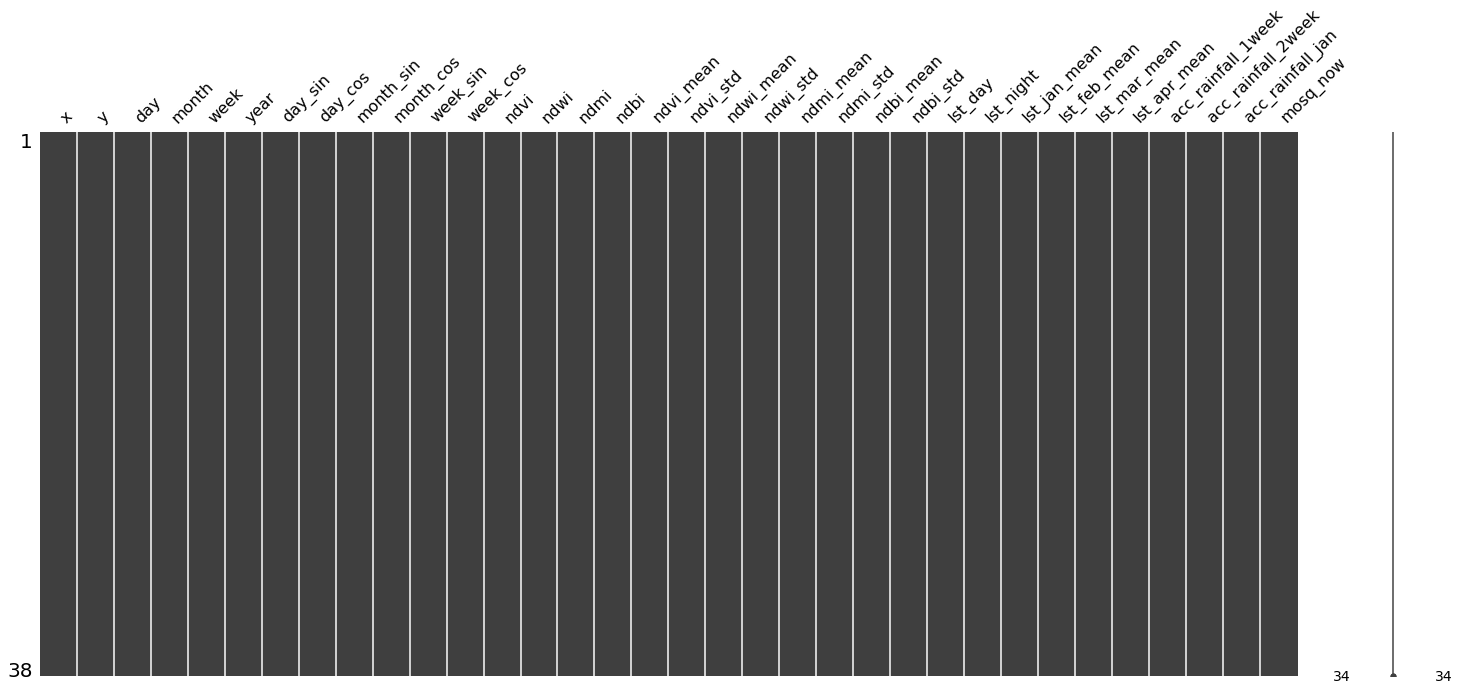

In [212]:
missingno.matrix(dataset_mamoth)

In [213]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [214]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [215]:
predictions = give_predictions(model, dataset_mamoth)

In [216]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.46197,40.60446,2023-08-01,74
1,22.07722,41.01522,2023-08-01,95
2,22.89198,40.65603,2023-08-01,138
3,23.95900,40.91196,2023-08-01,124
4,23.69747,40.49593,2023-08-01,73
...,...,...,...,...
33,23.87955,40.08302,2023-08-01,109
34,23.28798,41.28841,2023-08-01,120
35,22.17237,40.79674,2023-08-01,86
36,22.65595,40.73784,2023-08-01,83


In [217]:
#This cell writes the mosquito predictions to a seperate .csv file

# mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_2010-2022.csv', index = False)

In [218]:
mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

dataset['x.approx'] = dataset['x'].apply(lambda x : round(x,5))
dataset['y.approx'] = dataset['y'].apply(lambda x : round(x,5))

mosqutio_predictions['x.approx'] = mosqutio_predictions['x'].apply(lambda x : round(x,5))
mosqutio_predictions['y.approx'] = mosqutio_predictions['y'].apply(lambda x : round(x,5))

In [219]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x.approx', 'y.approx', 'dt_placement'])

In [220]:
dataset['distance'] = dataset.apply(lambda row: compute_distance(row, x1='x_x', y1 = 'y_x', x2 = 'x_y', y2 = 'y_y'), axis=1)

In [221]:
dataset.distance.max()

0.0

In [222]:
dataset.drop(columns=['x.approx', 'y.approx', 'x_y', 'y_y', 'distance'], axis=1, inplace=True)
dataset.rename(columns={"x_x": "x", "y_x": "y"}, inplace=True)

In [223]:
dataset.reset_index(inplace=True, drop=True)

<AxesSubplot:>

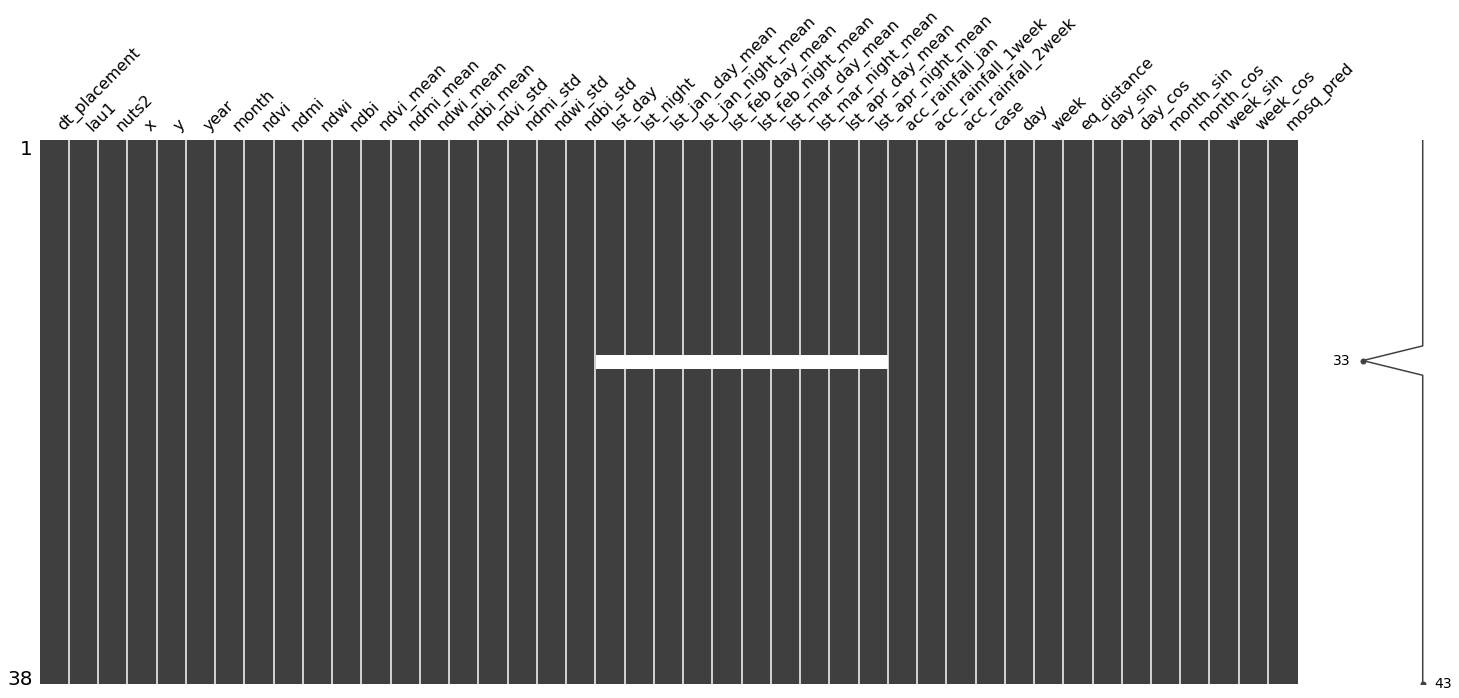

In [224]:
missingno.matrix(dataset)

### Add Demographic features ###

In [225]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_WEB_Demographics_Processed.csv', encoding = enc)

In [226]:
df_demographics

,lau1,nuts2,nuts3,area,population_density,population
0,αβδηρων,ανατολικης μακεδονιας και θρακης,ξανθης,352.0,54.0,17860.0
1,αγαθονησιου,νοτιου αιγαιου,καλυμνου,14.5,12.8,203.0
2,αγιας,θεσσαλιας,λαρισας,661.8,17.3,10705.0
3,αγιας βαρβαρας,αττικης,δυτικου τομεα αθηνων,2.4,10925.9,26759.0
4,αγιας παρασκευης,αττικης,βορειου τομεα αθηνων,7.9,7557.5,62157.0
...,...,...,...,...,...,...
327,χανιων,κρητης,χανιων,351.3,309.3,110646.0
328,χερσονησου,κρητης,ηρακλειου,272.2,98.2,27229.0
329,χιου,βορειου αιγαιου,χιου,842.3,61.0,50483.0
330,ωραιοκαστρου,κεντρικης μακεδονιας,θεσσαλονικης,217.9,175.8,40114.0


In [227]:
df_demographics_nuts2 = df_demographics.query(f"nuts2 == '{NUTS2_EL}'").copy()

In [228]:
df_demographics_nuts2.drop(columns=['nuts2', 'nuts3'], inplace=True)
df_demographics_nuts2.reset_index(inplace=True, drop=True)

In [229]:
df_demographics_nuts2

,lau1,area,population_density,population
0,αλεξανδρειας,478.8,86.8,38293.0
1,αλμωπιας,985.8,28.0,24924.0
2,αμπελοκηπων μενεμενης,9.8,5319.1,49674.0
3,αμφιπολης,411.8,22.3,7169.0
4,αριστοτελη,747.0,24.5,16994.0
...,...,...,...,...
33,σιθωνιας,516.8,24.0,11631.0
34,σιντικης,1103.4,20.1,18532.0
35,σκυδρας,239.5,84.3,18080.0
36,χαλκηδονος,391.5,86.0,29951.0


In [230]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

['ναουσας']

Length: 1


In [231]:
df_demographics_nuts2['lau1'] = df_demographics_nuts2['lau1'].apply(lambda x : x.replace('ηρωικης πολεως ναουσας','ναουσας'))


In [232]:
names_from_merged = dataset["lau1"].drop_duplicates().sort_values().tolist()
names_from_demographics = df_demographics_nuts2["lau1"].drop_duplicates().sort_values().tolist()
diff = []

for element in names_from_merged:
    if element not in names_from_demographics:
        diff.append(element)
        

print(f"{diff}\n\nLength: {len(diff)}")

[]

Length: 0


In [233]:
dataset = pd.merge(dataset, df_demographics_nuts2,  how='left', on=['lau1'])

<AxesSubplot:>

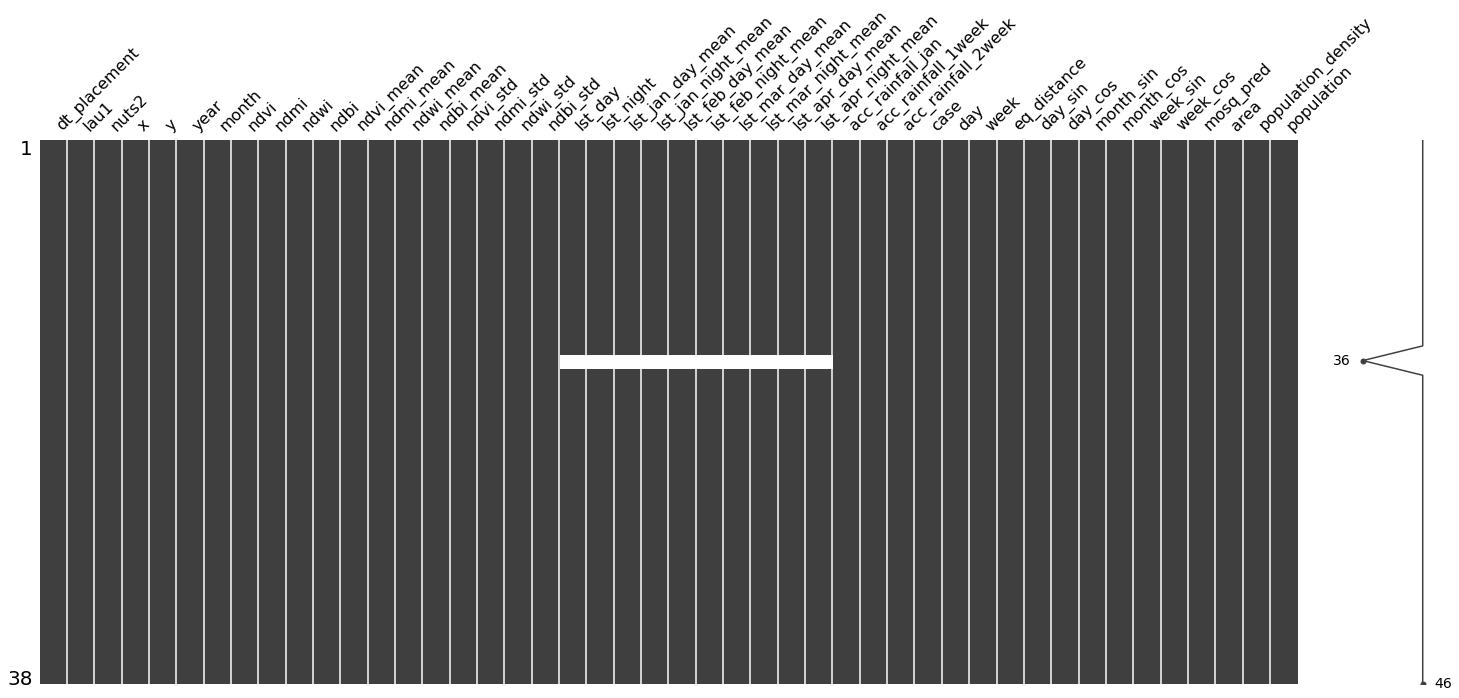

In [234]:
missingno.matrix(dataset)

In [235]:
missing = describe_dataframe(dataset)

In [236]:
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,case,day,week,eq_distance,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,area,population_density,population
0,2023-08-01,αλεξανδρειας,κεντρικης μακεδονιας,22.46197,40.60446,2023,8,0.611207,0.249284,-0.532555,-0.249284,0.599636,0.238649,-0.526441,-0.238649,0.081898,0.079507,0.055983,0.079507,15244.681818,14730.909091,14233.023324,13742.925517,14246.443821,13679.490252,14716.803345,13936.292447,14878.598181,14104.363400,187.946484,0.000000,0.000000,0,1,31,46.40326,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,74,478.8,86.8,38293.0
1,2023-08-01,αλμωπιας,κεντρικης μακεδονιας,22.07722,41.01522,2023,8,0.617810,0.191093,-0.540819,-0.191093,0.619570,0.195880,-0.540852,-0.195880,0.051798,0.048885,0.034330,0.048885,15115.203704,14598.685185,14119.434696,13753.508077,14136.170956,13638.922320,14413.543876,13849.215313,14492.704601,13981.248751,315.981766,0.000000,0.000000,0,1,31,46.57952,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,95,985.8,28.0,24924.0
2,2023-08-01,αμπελοκηπων μενεμενης,κεντρικης μακεδονιας,22.89198,40.65603,2023,8,0.113069,-0.034805,-0.143001,0.034805,0.154827,-0.024789,-0.182593,0.024789,0.063708,0.027689,0.055943,0.027689,15566.000000,14919.000000,14276.571429,13837.333333,14251.000000,13783.769231,14595.538462,13913.571429,14852.400000,14251.000000,416.613286,0.000000,0.000000,0,1,31,46.65786,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,138,9.8,5319.1,49674.0
3,2023-08-01,αμφιπολης,κεντρικης μακεδονιας,23.95900,40.91196,2023,8,0.408284,0.095824,-0.396856,-0.095824,0.358557,0.085568,-0.347080,-0.085568,0.065723,0.054425,0.052317,0.054425,15317.333333,14721.733333,14190.258047,13813.177518,14152.264350,13678.325152,14491.641758,13900.571616,14684.499025,14019.193016,127.404946,0.000000,0.000000,0,1,31,47.41120,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,124,411.8,22.3,7169.0
4,2023-08-01,αριστοτελη,κεντρικης μακεδονιας,23.69747,40.49593,2023,8,0.660292,0.286775,-0.565762,-0.286775,0.646614,0.276531,-0.555794,-0.276531,0.055642,0.054578,0.039862,0.054578,15080.972222,14677.750000,14205.938677,13846.023913,14130.189038,13790.567289,14425.631685,13899.748697,14520.483624,14026.554236,341.156538,1.943263,1.943263,0,1,31,46.92004,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,73,747.0,24.5,16994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2023-08-01,σιθωνιας,κεντρικης μακεδονιας,23.87955,40.08302,2023,8,0.438280,0.084336,-0.378407,-0.084336,0.443564,0.087266,-0.379178,-0.087266,0.069341,0.056444,0.044599,0.056444,15148.647059,14705.705882,14276.043954,13949.028760,14157.786455,13859.534262,14386.801183,13975.625045,14547.221120,14084.139273,366.321054,0.520809,0.886483,0,1,31,46.65706,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,109,516.8,24.0,11631.0
34,2023-08-01,σιντικης,κεντρικης μακεδονιας,23.28798,41.28841,2023,8,0.539904,0.166644,-0.472450,-0.166644,0.541231,0.172963,-0.472264,-0.172963,0.075524,0.057162,0.056444,0.057162,15205.596491,14714.947368,14170.271192,13791.940105,14082.611674,13663.319826,14424.257584,13880.510232,14524.909828,14004.885037,196.580264,0.030951,0.030951,0,1,31,47.40319,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,120,1103.4,20.1,18532.0
35,2023-08-01,σκυδρας,κεντρικης μακεδονιας,22.17237,40.79674,2023,8,0.488366,0.102494,-0.457579,-0.102494,0.458745,0.086793,-0.432163,-0.086793,0.054017,0.047259,0.036898,0.047259,15403.666667,14660.500000,14260.696970,13770.855395,14293.351175,13677.376225,14622.630456,13919.103241,14745.332197,14115.56

In [237]:
dataset = calculate_mosq_previous(dataset)

In [238]:
dataset = convert_temperature(dataset)

<AxesSubplot:>

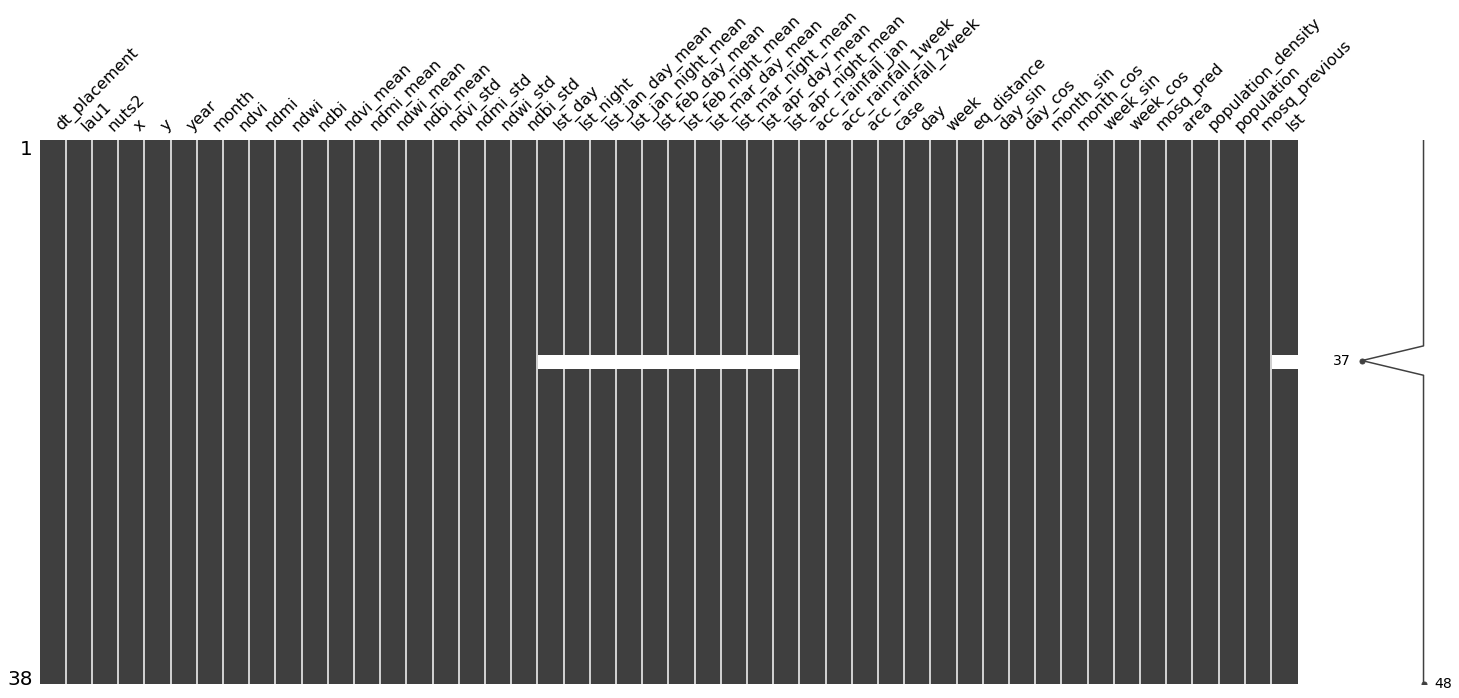

In [239]:
missingno.matrix(dataset)

In [240]:
dataset['case'].value_counts()

0    38
Name: case, dtype: int64

In [241]:
dataset = dataset.astype({'mosq_pred' : 'int', 'mosq_previous' : 'int'})

In [242]:
dataset['case'].value_counts()

0    38
Name: case, dtype: int64

In [243]:
cols = dataset.columns

In [244]:
cols

Index(['dt_placement', 'lau1', 'nuts2', 'x', 'y', 'year', 'month', 'ndvi',
       'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week', 'case',
       'day', 'week', 'eq_distance', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'week_sin', 'week_cos', 'mosq_pred', 'area',
       'population_density', 'population', 'mosq_previous', 'lst'],
      dtype='object')

In [245]:
len(cols)

48

In [246]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 
                 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 
                 'month_cos', 'week_sin', 'week_cos', 'area', 'population',
                 'population_density', 'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
                 'lst_day', 'lst_night','lst_jan_day_mean', 'lst_jan_night_mean', 
                 'lst_feb_day_mean','lst_feb_night_mean', 'lst_mar_day_mean', 
                 'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
                 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
                 'mosq_pred', 'mosq_previous', 'case']

In [247]:
len(rearranged_columns)

48

In [248]:
dataset = dataset[rearranged_columns].copy()

In [249]:
dataset

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,22.46197,40.60446,2023-08-01,κεντρικης μακεδονιας,αλεξανδρειας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,478.8,38293.0,86.8,46.40326,0.611207,0.249284,-0.532555,-0.249284,0.599636,0.238649,-0.526441,-0.238649,0.081898,0.079507,0.055983,0.079507,26.605909,31.743636,21.468182,11.510466,1.708510,11.778876,0.439805,21.186067,5.575849,24.421964,8.937268,0.000000,0.000000,187.946484,74,0,0
1,22.07722,41.01522,2023-08-01,κεντρικης μακεδονιας,αλμωπιας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,985.8,24924.0,28.0,46.57952,0.617810,0.191093,-0.540819,-0.191093,0.619570,0.195880,-0.540852,-0.195880,0.051798,0.048885,0.034330,0.048885,23.988889,29.154074,18.823704,9.238694,1.920162,9.573419,-0.371554,15.120878,3.834306,16.704092,6.474975,0.000000,0.000000,315.981766,95,0,0
2,22.89198,40.65603,2023-08-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.113069,-0.034805,-0.143001,0.034805,0.154827,-0.024789,-0.182593,0.024789,0.063708,0.027689,0.055943,0.027689,31.700000,38.170000,25.230000,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,0.000000,0.000000,416.613286,138,0,0
3,23.95900,40.91196,2023-08-01,κεντρικης μακεδονιας,αμφιπολης,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,411.8,7169.0,22.3,47.41120,0.408284,0.095824,-0.396856,-0.095824,0.358557,0.085568,-0.347080,-0.085568,0.065723,0.054425,0.052317,0.054425,27.240667,33.196667,21.284667,10.655161,3.113550,9.895287,0.416503,16.682835,4.861432,20.539981,7.233860,0.000000,0.000000,127.404946,124,0,0
4,23.69747,40.49593,2023-08-01,κεντρικης μακεδονιας,αριστοτελη,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,747.0,16994.0,24.5,46.92004,0.660292,0.286775,-0.565762,-0.286775,0.646614,0.276531,-0.555794,-0.276531,0.055642,0.054578,0.039862,0.054578,24.437222,28.469444,20.405000,10.968774,3.770478,9.453781,2.661346,15.362634,4.844974,17.259672,7.381085,1.943263,1.943263,341.156538,73,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,23.87955,40.08302,2023-08-01,κεντρικης μακεδονιας,σιθωνιας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,516.8,11631.0,24.0,46.65706,0.438280,0.084336,-0.378407,-0.084336,0.443564,0.087266,-0.379178,-0.087266,0.069341,0.056444,0.044599,0.056444,25.393529,29.822941,20.964118,12.370879,5.830575,10.005729,4.040685,14.586024,6.362501,17.794422,8.532785,0.520809,0.886483,366.321054,109,0,0
34,23.28798,41.28841,2023-08-01,κεντρικης μακεδονιας,σιντικης,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,1103.4,18532.0,20.1,47.40319,0.539904,0.166644,-0.472450,-0.166644,0.541231,0.172963,-0.472264,-0.172963,0.075524,0.057162,0.056444,0.057162,26.055439,30.961930,21.148947,10.255424,2.688802,8.502233,0.116397,15.335152,4.460205,17.348197,6.947701,0.030951,0.030951,196.580264,120,0,0
35,22.17237,40.79674,2023-08-01,κεντρικης μακεδονιας,σκυδρας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,239.5,18080.0,84.3,46.43262,0.488366,0.102494,-0.457579,-0.102494,0.458745,0.086793,-0.432163,-0.086793,0.054017,0.047259,0.036898,0.047259,27.491667,34.923333,20.060000,12.063939,2.267108,12.717023,0.397525,19.302609,5.232065,21.756644,9.161210,0.000000,0.000000,184.062619,86,0,0
36,22.65595,40.73784,2023-08-

### Add geomorphological features ###

In [250]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [251]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 8.200838003125297


In [252]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [253]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,22.46197,40.60446,2023-08-01,κεντρικης μακεδονιας,αλεξανδρειας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,478.8,38293.0,86.8,46.40326,0.611207,0.249284,-0.532555,-0.249284,0.599636,0.238649,-0.526441,-0.238649,0.081898,0.079507,0.055983,0.079507,26.605909,31.743636,21.468182,11.510466,1.708510,11.778876,0.439805,21.186067,5.575849,24.421964,8.937268,0.000000,0.000000,187.946484,74,0,0,18483.883785,1629.598106,4,120.472193,7.866005,180.191380,0.0,1.400071
1,22.07722,41.01522,2023-08-01,κεντρικης μακεδονιας,αλμωπιας,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,985.8,24924.0,28.0,46.57952,0.617810,0.191093,-0.540819,-0.191093,0.619570,0.195880,-0.540852,-0.195880,0.051798,0.048885,0.034330,0.048885,23.988889,29.154074,18.823704,9.238694,1.920162,9.573419,-0.371554,15.120878,3.834306,16.704092,6.474975,0.000000,0.000000,315.981766,95,0,0,25701.766035,44.089931,2,194.572797,144.613300,181.767317,0.0,113.550432
2,22.89198,40.65603,2023-08-01,κεντρικης μακεδονιας,αμπελοκηπων μενεμενης,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,9.8,49674.0,5319.1,46.65786,0.113069,-0.034805,-0.143001,0.034805,0.154827,-0.024789,-0.182593,0.024789,0.063708,0.027689,0.055943,0.027689,31.700000,38.170000,25.230000,12.381429,3.596667,11.870000,2.525385,18.760769,5.121429,23.898000,11.870000,0.000000,0.000000,416.613286,138,0,0,1013.723139,1259.926671,2,166.963790,4.655965,180.457193,0.0,24.343007
3,23.95900,40.91196,2023-08-01,κεντρικης μακεδονιας,αμφιπολης,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,411.8,7169.0,22.3,47.41120,0.408284,0.095824,-0.396856,-0.095824,0.358557,0.085568,-0.347080,-0.085568,0.065723,0.054425,0.052317,0.054425,27.240667,33.196667,21.284667,10.655161,3.113550,9.895287,0.416503,16.682835,4.861432,20.539981,7.233860,0.000000,0.000000,127.404946,124,0,0,14413.246350,196.335052,5,220.810138,250.710581,185.823044,0.0,25.464784
4,23.69747,40.49593,2023-08-01,κεντρικης μακεδονιας,αριστοτελη,1,8,31,2023,0.201299,0.97953,-0.866025,-0.5,-0.508531,-0.861044,747.0,16994.0,24.5,46.92004,0.660292,0.286775,-0.565762,-0.286775,0.646614,0.276531,-0.555794,-0.276531,0.055642,0.054578,0.039862,0.054578,24.437222,28.469444,20.405000,10.968774,3.770478,9.453781,2.661346,15.362634,4.844974,17.259672,7.381085,1.943263,1.943263,341.156538,73,0,0,11468.297401,1749.385768,22,273.587292,768.043224,181.562024,0.0,1.033661


<AxesSubplot:>

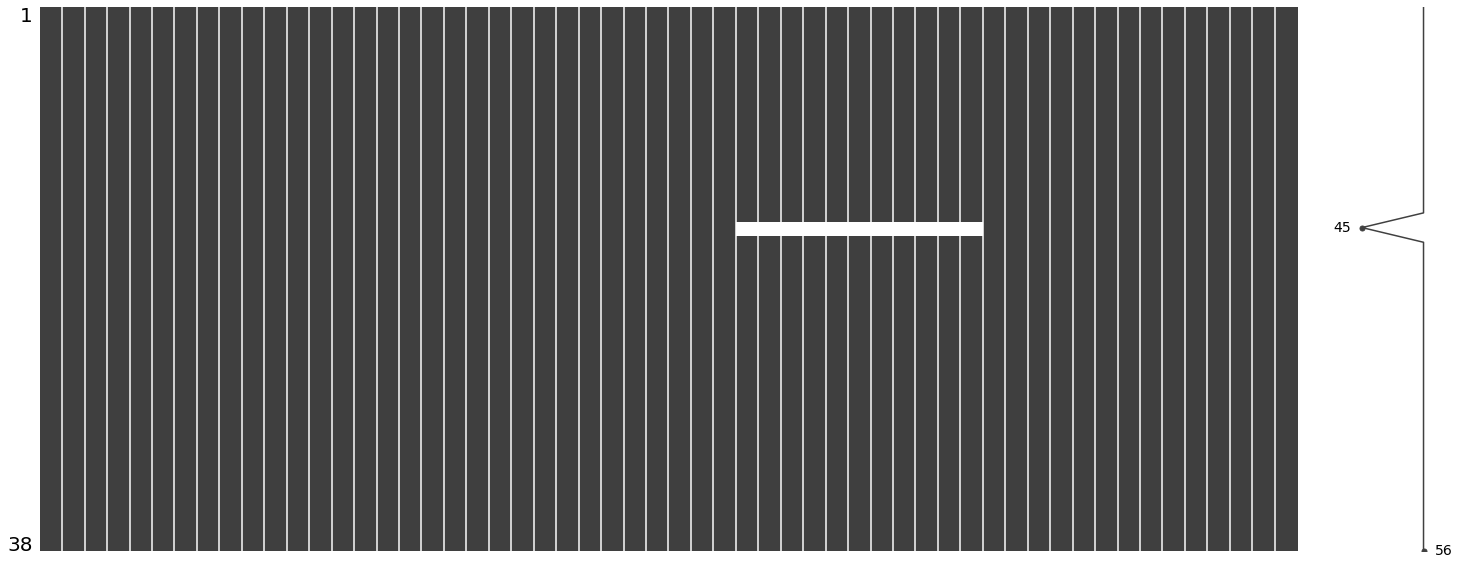

In [254]:
missingno.matrix(dataset)

In [255]:
cols = dataset.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [256]:
len(cols)

56

In [257]:
rearranged_columns = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [258]:
len(rearranged_columns)

56

In [259]:
dataset = dataset[rearranged_columns]

### Add Landcover features ###

In [260]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [261]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [262]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))
    

In [263]:
data_years = dataset['year'].unique().tolist()

In [264]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [265]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2023
Min distance: 0.0
Max distance: 8.200838003125297


In [266]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

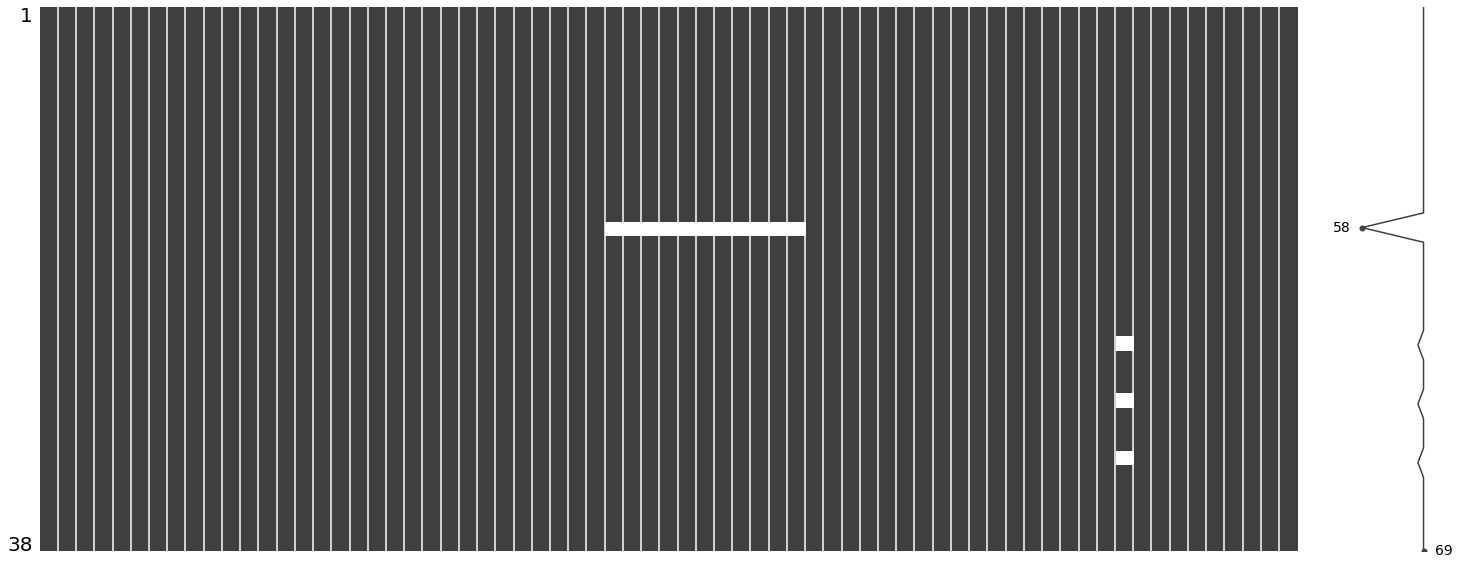

In [267]:
missingno.matrix(dataset_final)

In [268]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case',
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment',
       'lc_prop3', 'lc_prop3_assessment', '

In [269]:
len(cols)

69

In [270]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 
       'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 
       'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 
       'lc_prop1', 'lc_prop1_assessment', 'lc_prop2', 'lc_prop2_assessment', 
       'lc_prop3', 'lc_prop3_assessment', 'lc_type1', 'lc_type2', 'lc_type3', 
       'lc_type4', 'lc_type5', 'lw', 'qc', 'mosq_pred', 'mosq_previous', 'case']

In [271]:
len(rearranged)

69

In [272]:
dataset_final = dataset_final[rearranged]

In [273]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_{YEAR}-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)